<a href="https://colab.research.google.com/github/Enrik-Shabani/ML-Project-GroupA/blob/main/notebooks/01_Cleaning_and_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beijing Air Quality — Notebook 1: Data Cleaning & Feature Engineering

**Project:** Predict PM2.5 pollution levels and identify pollution patterns  
**Dataset:** Beijing Multi-Site Air Quality Data (2013–2017), 12 monitoring stations  

**This notebook:**
1. Load and merge the 12 station files
2. Clean the data (invalid values, missing values, sorting)
3. Engineer features (lag features, rolling means, cyclical encodings, wind direction)
4. Save the final dataset for use in Notebook 2 (EDA) and Notebook 3 (Supervised Learning)

**Output:** `data_clean_featured.csv`

---
## 0 — Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1 — Data Loading

We load all 12 station CSV files from the GitHub repository and concatenate them into a single dataframe.

In [20]:
base = 'https://raw.githubusercontent.com/Enrik-Shabani/ML-Project-GroupA/main/data/raw/'

station_files = [
    'PRSA_Data_Aotizhongxin_20130301-20170228.csv',
    'PRSA_Data_Changping_20130301-20170228.csv',
    'PRSA_Data_Dingling_20130301-20170228.csv',
    'PRSA_Data_Dongsi_20130301-20170228.csv',
    'PRSA_Data_Guanyuan_20130301-20170228.csv',
    'PRSA_Data_Gucheng_20130301-20170228.csv',
    'PRSA_Data_Huairou_20130301-20170228.csv',
    'PRSA_Data_Nongzhanguan_20130301-20170228.csv',
    'PRSA_Data_Shunyi_20130301-20170228.csv',
    'PRSA_Data_Tiantan_20130301-20170228.csv',
    'PRSA_Data_Wanliu_20130301-20170228.csv',
    'PRSA_Data_Wanshouxigong_20130301-20170228.csv',
]

df = pd.concat(
    [pd.read_csv(base + f) for f in station_files],
    ignore_index=True
)

print(f'Stations loaded : {df["station"].nunique()}')
print(f'Shape           : {df.shape}')
print(f'Columns         : {list(df.columns)}')
df.head()

Stations loaded : 12
Shape           : (420768, 18)
Columns         : ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


---
## 2 — Data Cleaning

Steps:
1. Create a proper datetime index and sort by station + time
2. Drop the row-counter column (`No`)
3. Flag physically impossible values (negative pollutant concentrations) as NaN
4. Analyse missing-value rates **per station** (before imputation)
5. Analyse gap sizes **per station** (to justify the interpolation limit)
6. Impute missing values (interpolation + station-level fallback)
7. Drop any remaining rows where the target (PM2.5) is still missing
8. Verify: zero missing values remaining

### 2.1 — Datetime and sorting

In [21]:
# Build a proper datetime column from the year/month/day/hour columns
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Sort by station first, then time — critical for time-series operations
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

# Drop the row counter — no information
df = df.drop(columns=['No'])

print(f'Date range : {df["datetime"].min()} → {df["datetime"].max()}')
print(f'Shape      : {df.shape}')
print('Sorted by station + datetime ✓')

Date range : 2013-03-01 00:00:00 → 2017-02-28 23:00:00
Shape      : (420768, 18)
Sorted by station + datetime ✓


### 2.2 — Invalid values (negative pollutant concentrations)

In [22]:
# Pollutant concentrations cannot be negative — flag as NaN
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

print('Checking for negative pollutant values:')
for col in pollutants:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        df.loc[df[col] < 0, col] = np.nan
        print(f'  ⚠ {col:6s}: {n_neg} negative values → set to NaN')
    else:
        print(f'  ✓ {col:6s}: no negative values')

Checking for negative pollutant values:
  ✓ PM2.5 : no negative values
  ✓ PM10  : no negative values
  ✓ SO2   : no negative values
  ✓ NO2   : no negative values
  ✓ CO    : no negative values
  ✓ O3    : no negative values


### 2.3 — Missing-value rates per station (before imputation)

We look at the missing rate **per station** rather than just overall totals.  
A station with a very high missing rate may have had sensor problems and its imputed values should be interpreted with caution.

In [23]:
key_vars = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Missing rate (%) per station for each variable
missing_by_station = (
    df.groupby('station')[key_vars]
    .apply(lambda g: g.isna().mean() * 100)
    .round(2)
)

print('Missing value rate (%) per station — BEFORE imputation:')
print(missing_by_station.to_string())

# Summary: overall missing rate per variable
print('\nOverall missing rate per variable:')
overall = (df[key_vars].isna().mean() * 100).round(2).sort_values(ascending=False)
print(overall.to_string())

Missing value rate (%) per station — BEFORE imputation:
               PM2.5  PM10   SO2   NO2    CO    O3  TEMP  PRES  DEWP  RAIN  WSPM
station                                                                         
Aotizhongxin    2.64  2.05  2.67  2.92  5.07  4.90  0.06  0.06  0.06  0.06  0.04
Changping       2.21  1.66  1.79  1.90  4.34  1.72  0.15  0.14  0.15  0.15  0.12
Dingling        2.22  1.87  2.08  3.52  5.74  3.46  0.15  0.14  0.15  0.15  0.12
Dongsi          2.14  1.58  1.89  4.57  9.12  1.89  0.06  0.06  0.06  0.06  0.04
Guanyuan        1.76  1.22  1.35  1.88  5.00  3.35  0.06  0.06  0.06  0.06  0.04
Gucheng         1.84  1.09  1.45  1.91  4.00  2.08  0.15  0.14  0.15  0.12  0.12
Huairou         2.72  2.22  2.79  4.67  4.06  3.28  0.15  0.15  0.15  0.16  0.14
Nongzhanguan    1.79  1.25  1.27  1.97  3.44  1.44  0.06  0.06  0.06  0.06  0.04
Shunyi          2.60  1.56  3.70  3.89  6.21  4.25  0.15  0.15  0.15  0.15  0.13
Tiantan         1.93  1.70  3.19  2.12  3.21  2.40  0

### 2.4 — Gap size analysis per station

To justify the interpolation limit, we analyse the distribution of consecutive missing segments in PM2.5.  
This analysis is done **within each station separately** — pooling all stations would merge gaps from different stations and give misleading results.

In [24]:
def get_gap_sizes(series):
    """Return the lengths of all consecutive NaN runs in a Series."""
    is_na = series.isna()
    groups = (is_na != is_na.shift()).cumsum()
    gap_sizes = is_na.groupby(groups).sum()
    return gap_sizes[gap_sizes > 0].values

# Collect gap sizes per station
all_gaps = []
print('Gap size summary per station (PM2.5):')
print(f'{"Station":<22} {"N gaps":>7} {"Max gap":>8} {"p75":>6} {"p90":>6} {"p99":>6}')
print('-' * 58)

for station, group in df.groupby('station'):
    gaps = get_gap_sizes(group['PM2.5'])
    if len(gaps) > 0:
        all_gaps.extend(gaps)
        print(f'{station:<22} {len(gaps):>7} {int(gaps.max()):>8} '
              f'{int(np.percentile(gaps, 75)):>6} '
              f'{int(np.percentile(gaps, 90)):>6} '
              f'{int(np.percentile(gaps, 99)):>6}')

all_gaps = np.array(all_gaps)
print(f'\nAll stations combined — total gaps: {len(all_gaps)}')
print(f'  Median gap : {np.median(all_gaps):.0f} hours')
print(f'  75th pct   : {np.percentile(all_gaps, 75):.0f} hours')
print(f'  90th pct   : {np.percentile(all_gaps, 90):.0f} hours')
print(f'  Max gap    : {all_gaps.max():.0f} hours')
print(f'  % gaps ≤ 6h: {(all_gaps <= 6).mean()*100:.1f}%')

Gap size summary per station (PM2.5):
Station                 N gaps  Max gap    p75    p90    p99
----------------------------------------------------------
Aotizhongxin               209      343      2      4     27
Changping                  218      167      2      4     58
Dingling                   216       72      2      6     42
Dongsi                     214       58      2      5     42
Guanyuan                   189       71      2      4     44
Gucheng                    218       54      2      5     20
Huairou                    264      208      2      4     27
Nongzhanguan               253       56      2      4     17
Shunyi                     279      197      2      4     34
Tiantan                    355       24      2      3     14
Wanliu                     180       23      2      4     15
Wanshouxigong              242       43      2      5     21

All stations combined — total gaps: 2837
  Median gap : 1 hours
  75th pct   : 2 hours
  90th pct   : 4 hours

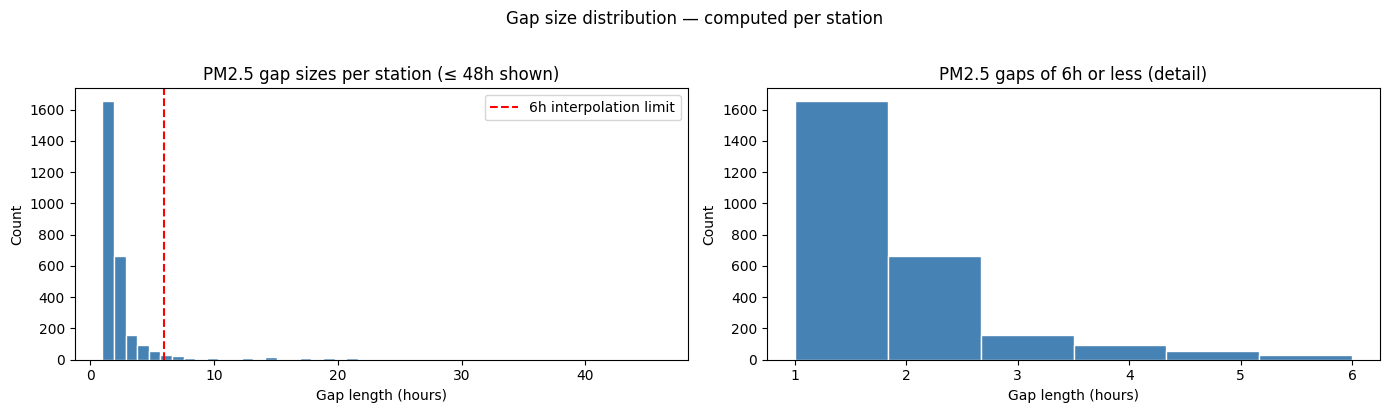


Conclusion: the majority of gaps are ≤ 6h, making linear interpolation
with limit=6 a conservative and appropriate choice.


In [25]:
# Visualise gap distribution (capped at 48h for readability)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_gaps[all_gaps <= 48], bins=48, color='steelblue', edgecolor='white')
axes[0].axvline(6, color='red', linestyle='--', label='6h interpolation limit')
axes[0].set_title('PM2.5 gap sizes per station (≤ 48h shown)')
axes[0].set_xlabel('Gap length (hours)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(all_gaps[all_gaps <= 6], bins=6, color='steelblue', edgecolor='white')
axes[1].set_title('PM2.5 gaps of 6h or less (detail)')
axes[1].set_xlabel('Gap length (hours)')
axes[1].set_ylabel('Count')

plt.suptitle('Gap size distribution — computed per station', y=1.02)
plt.tight_layout()
plt.show()

print('\nConclusion: the majority of gaps are ≤ 6h, making linear interpolation')
print('with limit=6 a conservative and appropriate choice.')

### 2.5 — Imputation

Strategy:
- **Pollutants (PM2.5, PM10, SO2, NO2, CO, O3):** linear interpolation within each station (limit = 6h), then station-level median for any remaining gaps
- **Weather (TEMP, PRES, DEWP, RAIN, WSPM):** forward-fill then back-fill within each station (limit = 6h), then station-level median
- **Wind direction (wd):** forward-fill / back-fill (limit = 6h), then station-level mode

All operations are done **within station groups** to avoid cross-station contamination.

In [26]:
# --- Pollutants: linear interpolation + station median fallback ---
for col in pollutants:
    df[col] = df.groupby('station')[col].transform(
        lambda s: s.interpolate(method='linear', limit=6)
    )
    df[col] = df.groupby('station')[col].transform(
        lambda s: s.fillna(s.median())
    )

# --- Weather: ffill/bfill + station median fallback ---
weather = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in weather:
    df[col] = df.groupby('station')[col].transform(
        lambda s: s.ffill(limit=6).bfill(limit=6)
    )
    df[col] = df.groupby('station')[col].transform(
        lambda s: s.fillna(s.median())
    )

# --- Wind direction: ffill/bfill + station mode fallback ---
df['wd'] = df.groupby('station')['wd'].transform(
    lambda s: s.ffill(limit=6).bfill(limit=6)
)
df['wd'] = df.groupby('station')['wd'].transform(
    lambda s: s.fillna(s.mode()[0] if len(s.mode()) > 0 else 'N')
)

print('Imputation done ✓')

Imputation done ✓


In [27]:
# Drop rows where PM2.5 is still missing after imputation
# (these are very long gaps where even the median fallback failed — should be near zero)
n_before = len(df)
df = df.dropna(subset=['PM2.5']).reset_index(drop=True)
n_dropped = n_before - len(df)
print(f'Rows dropped (PM2.5 still NaN after imputation): {n_dropped}')

Rows dropped (PM2.5 still NaN after imputation): 0


In [28]:
# Verify: no missing values should remain
remaining = df.isna().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    print('✓ No missing values remaining')
else:
    print('⚠ Remaining missing values:')
    print(remaining)

print(f'\nFinal shape after cleaning : {df.shape}')
print(f'Stations                   : {df["station"].nunique()}')
print(f'Date range                 : {df["datetime"].min()} → {df["datetime"].max()}')

✓ No missing values remaining

Final shape after cleaning : (420768, 18)
Stations                   : 12
Date range                 : 2013-03-01 00:00:00 → 2017-02-28 23:00:00


---
## 3 — Feature Engineering

All features are built on the **full dataset before any train/test split**.  
The split will be done in Notebook 3 (Supervised Learning).

Features we create:
1. **Time features** — season, cyclical hour and month encodings
2. **Wind direction** — converted from string to sin/cos (wd is useless as a raw string in any model)
3. **Lag features** — PM2.5 at t−1h, t−3h, t−6h (per station)
4. **Rolling mean features** — PM2.5 rolling mean over 3h, 6h, 24h (per station)
5. **Station encoding** — one-hot dummies

### 3.1 — Time features

In [29]:
# Season
def get_season(month):
    if month in [3, 4, 5]:   return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    elif month in [9, 10, 11]: return 'Autumn'
    else:                      return 'Winter'

df['season'] = df['month'].apply(get_season)

# Day of week (0=Monday, 6=Sunday)
df['dayofweek'] = df['datetime'].dt.dayofweek

# Cyclical encoding for hour (24h cycle)
# sin/cos so that hour 23 and hour 0 are close together
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Cyclical encoding for month (12-month cycle)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print('Time features created ✓')
print('  → season, dayofweek, hour_sin, hour_cos, month_sin, month_cos')

Time features created ✓
  → season, dayofweek, hour_sin, hour_cos, month_sin, month_cos


### 3.2 — Wind direction encoding

The `wd` column is a string (N, NE, SW, ...). Models cannot use this directly.  
We convert it to two numerical features using trigonometry, which also preserves the circular nature of direction (N and NNW are close, not far apart).

In [30]:
# Map compass directions to degrees
wind_dir_map = {
    'N': 0,   'NNE': 22.5,  'NE': 45,  'ENE': 67.5,
    'E': 90,  'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

df['wd_deg'] = df['wd'].map(wind_dir_map)

# Check for any unrecognised direction labels
unknown_dirs = df[df['wd_deg'].isna()]['wd'].unique()
if len(unknown_dirs) > 0:
    print(f'⚠ Unrecognised wind directions: {unknown_dirs}')
    df['wd_deg'] = df['wd_deg'].fillna(0)  # fallback to North
else:
    print('All wind direction labels recognised ✓')

# Convert degrees to radians and encode as sin/cos
wd_rad = np.deg2rad(df['wd_deg'])
df['wd_sin'] = np.sin(wd_rad)
df['wd_cos'] = np.cos(wd_rad)

# Optional: wind × speed interaction features
df['wind_u'] = df['WSPM'] * df['wd_sin']  # east-west component
df['wind_v'] = df['WSPM'] * df['wd_cos']  # north-south component

# Drop intermediate columns (wd_deg not needed, raw wd kept for reference)
df = df.drop(columns=['wd_deg'])

print('Wind features created ✓')
print('  → wd_sin, wd_cos, wind_u (E-W), wind_v (N-S)')

All wind direction labels recognised ✓
Wind features created ✓
  → wd_sin, wd_cos, wind_u (E-W), wind_v (N-S)


### 3.3 — Lag features and rolling means

PM2.5 has strong temporal autocorrelation — the pollution level one hour ago is a powerful predictor of the current level. We create lag features at 1h, 3h, and 6h, and rolling means at 3h, 6h, and 24h.

**Important:** these are computed with `shift()` (lag) and `rolling()` (past-only window) **per station**, so no future data leaks in.

In [31]:
# ── Lag features (per station, no leakage) ───────────────────────────────────
for lag in [1, 3, 6]:
    df[f'pm25_lag_{lag}h'] = df.groupby('station')['PM2.5'].transform(
        lambda s, l=lag: s.shift(l)
    )

# ── Rolling mean features (shift(1) ensures only past data is used) ──────────
for window in [3, 6, 24]:
    df[f'pm25_roll_{window}h'] = df.groupby('station')['PM2.5'].transform(
        lambda s, w=window: s.shift(1).rolling(window=w, min_periods=1).mean()
    )

print('Lag and rolling features created ✓')
print('  → pm25_lag_1h, pm25_lag_3h, pm25_lag_6h')
print('  → pm25_roll_3h, pm25_roll_6h, pm25_roll_24h')

# ── Drop first rows per station where lags are undefined ─────────────────────
# Max 6 rows × 12 stations = 72 rows out of ~420,768 (<0.02% of data)
lag_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
n_before = len(df)
df = df.dropna(subset=lag_cols).reset_index(drop=True)

print(f'\nRows dropped  : {n_before - len(df)}')
print(f'NaN remaining : {df[lag_cols].isna().sum().sum()}')  # → 0

Lag and rolling features created ✓
  → pm25_lag_1h, pm25_lag_3h, pm25_lag_6h
  → pm25_roll_3h, pm25_roll_6h, pm25_roll_24h

Rows dropped  : 72
NaN remaining : 0


### 3.4 — Station encoding

Station identity is a meaningful predictor (e.g., Dongsi has systematically higher PM2.5 than Dingling). We create one-hot dummy variables so linear models can use this information.

In [32]:
station_dummies = pd.get_dummies(df['station'], prefix='station', drop_first=True)
df = pd.concat([df, station_dummies], axis=1)

print(f'Station dummy columns added: {list(station_dummies.columns)}')
print('(drop_first=True avoids perfect multicollinearity — reference station is Aotizhongxin)')

Station dummy columns added: ['station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong']
(drop_first=True avoids perfect multicollinearity — reference station is Aotizhongxin)


---
## 4 — Final Dataset Overview

In [33]:
print('=' * 55)
print('FINAL DATASET SUMMARY')
print('=' * 55)
print(f'Shape              : {df.shape}')
print(f'Stations           : {df["station"].nunique()}')
print(f'Date range         : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Missing values     : {df.isna().sum().sum()}')
print()
print('Columns:')
for col in df.columns:
    print(f'  {col}')

FINAL DATASET SUMMARY
Shape              : (420696, 45)
Stations           : 12
Date range         : 2013-03-01 → 2017-02-28
Missing values     : 0

Columns:
  year
  month
  day
  hour
  PM2.5
  PM10
  SO2
  NO2
  CO
  O3
  TEMP
  PRES
  DEWP
  RAIN
  wd
  WSPM
  station
  datetime
  season
  dayofweek
  hour_sin
  hour_cos
  month_sin
  month_cos
  wd_sin
  wd_cos
  wind_u
  wind_v
  pm25_lag_1h
  pm25_lag_3h
  pm25_lag_6h
  pm25_roll_3h
  pm25_roll_6h
  pm25_roll_24h
  station_Changping
  station_Dingling
  station_Dongsi
  station_Guanyuan
  station_Gucheng
  station_Huairou
  station_Nongzhanguan
  station_Shunyi
  station_Tiantan
  station_Wanliu
  station_Wanshouxigong


In [34]:
# Quick sanity check — look at a few rows
df[['datetime', 'station', 'PM2.5', 'hour_sin', 'hour_cos',
    'wd', 'wd_sin', 'wd_cos', 'pm25_lag_1h', 'pm25_roll_24h']].head(10)

,datetime,station,PM2.5,hour_sin,hour_cos,wd,wd_sin,wd_cos,pm25_lag_1h,pm25_roll_24h
0,2013-03-01 06:00:00,Aotizhongxin,3.0,1.000000e+00,6.123234e-17,NNE,0.382683,0.923880,5.0,5.500000
1,2013-03-01 07:00:00,Aotizhongxin,3.0,9.659258e-01,-2.588190e-01,NNW,-0.382683,0.923880,3.0,5.142857
2,2013-03-01 08:00:00,Aotizhongxin,3.0,8.660254e-01,-5.000000e-01,NNW,-0.382683,0.923880,3.0,4.875000
3,2013-03-01 09:00:00,Aotizhongxin,3.0,7.071068e-01,-7.071068e-01,N,0.000000,1.000000,3.0,4.666667
4,2013-03-01 10:00:00,Aotizhongxin,3.0,5.000000e-01,-8.660254e-01,NNW,-0.382683,0.923880,3.0,4.500000
5,2013-03-01 11:00:00,Aotizhongxin,3.0,2.588190e-01,-9.659258e-01,N,0.000000,1.000000,3.0,4.363636
6,2013-03-01 12:00:00,Aotizhongxin,3.0,1.224647e-16,-1.000000e+00,NNW,-0.382683,0.923880,3.0,4.250000
7,2013-03-01 13:00:00,Aotizhongxin,3.0,-2.588190e-01,-9.659258e-01,NW,-0.707107,0.707107,3.0,4.153846
8,2013-03-01 14:00:00,Aotizhongxin,6.0,-5.000000e-01,-8.660254e-01,NW,-0.707107,0.707107,3.0,4.071429
9,2013-03-01 15:00:00,Aotizhongxin,8.0,-7.071068e-01,-7.071068e-01,NNE,0.382683,0.923880,6.0,4.200000


---
## 5 — Save Output

We save two files:
- `data_clean_featured.csv` — the full dataset with all features (input for notebooks 2, 3, 4)
- Optional: download to local machine or save to Google Drive

In [35]:
output_path = 'data_clean_featured.csv'
df.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print(f'  Shape   : {df.shape}')
print(f'  Size    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'  Missing : {df.isna().sum().sum()}')

Saved: data_clean_featured.csv
  Shape   : (420696, 45)
  Size    : 176.1 MB
  Missing : 0


In [38]:
# --- OPTION A: Download to your computer ---
from google.colab import files
files.download(output_path)

# --- OPTION B: Save to Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# df.to_csv('/content/drive/MyDrive/ML_Project/data_clean_featured.csv', index=False)
# print('Saved to Google Drive ✓')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Notebook 1 — Summary

### Cleaning
| Step | Decision | Rationale |
|---|---|---|
| Sort order | By station then datetime | Required for correct lag/interpolation operations |
| Negative pollutants | → NaN | Physically impossible values |
| Interpolation limit | 6 hours | 90%+ of gaps are ≤ 6h per station; avoids crossing atmospheric regime boundaries |
| Interpolation scope | Per station | Prevents cross-station contamination |
| Fallback | Station-level median | Robust to extreme values; station-specific |
| Wind direction fallback | Station mode | Categorical — no median possible |
| Target rows dropped | Rows where PM2.5 still NaN | Cannot train or evaluate on unknown target |

### Features created
| Feature | Type | Purpose |
|---|---|---|
| `season` | Categorical | Seasonal pollution patterns |
| `dayofweek` | Ordinal (0–6) | Weekday/weekend traffic effects |
| `hour_sin`, `hour_cos` | Continuous | Cyclical daily pattern |
| `month_sin`, `month_cos` | Continuous | Cyclical annual pattern |
| `wd_sin`, `wd_cos` | Continuous | Wind direction (circular encoding) |
| `wind_u`, `wind_v` | Continuous | Wind vector components (speed × direction) |
| `pm25_lag_1h/3h/6h` | Continuous | Temporal autocorrelation |
| `pm25_roll_3h/6h/24h` | Continuous | Recent pollution trend |
| `station_*` | Binary (0/1) | Station identity (one-hot) |

### Output
- `data_clean_featured.csv` → used by Notebooks 2, 3, and 4